In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
# Load EMI Dataset
file_path = "../data/dagem d.xlsx"

raw_df = pd.read_excel(
    file_path,
    sheet_name="data"
)

# Preview
raw_df.head()

,NAME,GEOGR2,GEOGR1,ELEVATION,Element,YEAR,Month,TIME,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,Bahir Dar (Airport),11.6027,37.322,1827,PRECIP,1992,10,09:00:00,4.4,3.5,0.0,0.0,2.9,6.3,2.3,0.0,16.3,5.2,8.0,24.5,12.6,0.0,1.3,6.4,26.6,0.0,7.1,21.2,0.0,2.8,4.7,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Bahir Dar (Airport),11.6027,37.322,1827,PRECIP,1992,11,09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,Bahir Dar (Airport),11.6027,37.322,1827,PRECIP,1992,12,09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Bahir Dar (Airport),11.6027,37.322,1827,PRECIP,1993,1,09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Bahir Dar (Airport),11.6027,37.322,1827,PRECIP,1993,2,09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [3]:
print("Shape:", raw_df.shape)

print("\nColumns:")
print(raw_df.columns.tolist())

Shape: (3425, 39)

Columns:
['NAME', 'GEOGR2', 'GEOGR1', 'ELEVATION', 'Element', 'YEAR', 'Month', 'TIME', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


In [4]:
# Unique meteorological variables
raw_df["Element"].unique()

array(['PRECIP', 'RELHUM', 'SUNHRS', 'TMPMAX', 'TMPMIN', 'TSL005',
       'TSL010', 'TSL020', 'TSL050', 'TSL100', 'WINDLY'], dtype=object)

In [5]:
# Check actual column names
raw_df.columns.tolist()

['NAME',
 'GEOGR2',
 'GEOGR1',
 'ELEVATION',
 'Element',
 'YEAR',
 'Month',
 'TIME',
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31]

In [6]:
# Daily columns (1–31) as integers
day_columns = list(range(1, 32))

# Convert wide format → long format
long_df = raw_df.melt(
    id_vars=[
        "NAME",
        "GEOGR1",
        "GEOGR2",
        "ELEVATION",
        "Element",
        "YEAR",
        "Month",
        "TIME"
    ],
    value_vars=day_columns,
    var_name="DAY",
    value_name="VALUE"
)

# Preview
long_df.head()

,NAME,GEOGR1,GEOGR2,ELEVATION,Element,YEAR,Month,TIME,DAY,VALUE
0,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1992,10,09:00:00,1,4.4
1,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1992,11,09:00:00,1,0.0
2,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1992,12,09:00:00,1,0.0
3,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1993,1,09:00:00,1,0.0
4,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1993,2,09:00:00,1,0.0


In [7]:
# Convert to numeric
long_df["DAY"] = pd.to_numeric(long_df["DAY"])

# Create date column safely
long_df["DATE"] = pd.to_datetime(
    dict(
        year=long_df["YEAR"],
        month=long_df["Month"],
        day=long_df["DAY"]
    ),
    errors="coerce"
)

# Remove invalid dates
long_df = long_df.dropna(subset=["DATE"])

# Preview
long_df.head()

,NAME,GEOGR1,GEOGR2,ELEVATION,Element,YEAR,Month,TIME,DAY,VALUE,DATE
0,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1992,10,09:00:00,1,4.4,1992-10-01
1,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1992,11,09:00:00,1,0.0,1992-11-01
2,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1992,12,09:00:00,1,0.0,1992-12-01
3,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1993,1,09:00:00,1,0.0,1993-01-01
4,Bahir Dar (Airport),37.322,11.6027,1827,PRECIP,1993,2,09:00:00,1,0.0,1993-02-01


In [8]:
# Remove rows with missing measurements
long_df = long_df.dropna(subset=["VALUE"])

print("Shape after cleaning:", long_df.shape)

Shape after cleaning: (99263, 11)


In [9]:
# Pivot meteorological variables into columns
climate_df = long_df.pivot_table(
    index="DATE",
    columns="Element",
    values="VALUE",
    aggfunc="mean"
).reset_index()

# Remove column index name
climate_df.columns.name = None

# Sort by date
climate_df = climate_df.sort_values("DATE")

# Preview
climate_df.head()

,DATE,PRECIP,RELHUM,SUNHRS,TMPMAX,TMPMIN,TSL005,TSL010,TSL020,TSL050,TSL100,WINDLY
0,1987-04-01,NaN,NaN,NaN,30.8,10.7,NaN,NaN,NaN,NaN,NaN,NaN
1,1987-04-02,NaN,NaN,NaN,32.5,10.6,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-04-03,NaN,NaN,NaN,32.5,21.5,NaN,NaN,NaN,NaN,NaN,NaN
3,1987-04-04,NaN,NaN,NaN,32.2,19.3,NaN,NaN,NaN,NaN,NaN,NaN
4,1987-04-05,NaN,NaN,NaN,32.2,18.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
climate_df.shape

(12844, 12)

In [11]:
# Missing values count
missing_values = climate_df.isnull().sum()

# Missing percentage
missing_percent = (
    climate_df.isnull().mean() * 100
).round(2)

# Combine into one table
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percent": missing_percent
})

# Sort descending
missing_table = missing_table.sort_values(
    by="Missing Percent",
    ascending=False
)

missing_table

,Missing Values,Missing Percent
TSL100,12538,97.62
TSL050,12476,97.13
TSL010,12447,96.91
TSL020,12416,96.67
TSL005,10983,85.51
WINDLY,8578,66.79
SUNHRS,8267,64.36
RELHUM,2282,17.77
PRECIP,2102,16.37
TMPMAX,426,3.32


In [12]:
# Missing values by year
yearly_missing = climate_df.copy()

yearly_missing["YEAR"] = yearly_missing["DATE"].dt.year

# Calculate yearly missing percentage
missing_by_year = yearly_missing.groupby("YEAR").apply(
    lambda x: x.isnull().mean() * 100
)

missing_by_year[[
    "PRECIP",
    "RELHUM",
    "SUNHRS",
    "WINDLY",
    "TMPMAX",
    "TMPMIN"
]]

,PRECIP,RELHUM,SUNHRS,WINDLY,TMPMAX,TMPMIN
YEAR,,,,,,
1987,100.000000,33.090909,33.090909,100.000000,0.000000,0.000000
1988,100.000000,66.939891,0.546448,100.000000,0.546448,0.819672
1989,100.000000,100.000000,17.857143,75.274725,0.824176,1.098901
1990,100.000000,100.000000,100.000000,79.310345,0.574713,0.287356
1991,100.000000,100.000000,100.000000,100.000000,0.400000,0.800000
1992,75.683060,75.136612,76.229508,80.874317,0.000000,0.000000
1993,14.246575,9.589041,15.342466,12.602740,22.191781,4.109589
1994,0.000000,0.000000,0.273973,0.547945,0.821918,0.547945
1995,0.000000,0.000000,0.000000,1.643836,0.000000,0.273973


In [13]:
# Keep only strong usable variables
climate_df = climate_df[[
    "DATE",
    "PRECIP",
    "RELHUM",
    "TMPMAX",
    "TMPMIN"
]]

# Preview
climate_df.head()

,DATE,PRECIP,RELHUM,TMPMAX,TMPMIN
0,1987-04-01,NaN,NaN,30.8,10.7
1,1987-04-02,NaN,NaN,32.5,10.6
2,1987-04-03,NaN,NaN,32.5,21.5
3,1987-04-04,NaN,NaN,32.2,19.3
4,1987-04-05,NaN,NaN,32.2,18.0


In [14]:
# Extract year
climate_df["YEAR"] = climate_df["DATE"].dt.year

# Keep reliable years only
climate_df = climate_df[
    climate_df["YEAR"] >= 1993
]

# Reset index
climate_df = climate_df.reset_index(drop=True)

# Preview
climate_df.head()

,DATE,PRECIP,RELHUM,TMPMAX,TMPMIN,YEAR
0,1993-01-01,0.0,44.75,27.6,8.6,1993
1,1993-01-02,0.0,47.25,27.5,7.6,1993
2,1993-01-03,0.0,42.00,27.0,7.5,1993
3,1993-01-04,0.0,45.75,27.0,13.5,1993
4,1993-01-05,0.0,43.25,28.0,11.7,1993


In [15]:
# Recheck missing values
missing_after_filter = pd.DataFrame({
    "Missing Count": climate_df.isnull().sum(),
    "Missing Percent": (
        climate_df.isnull().mean() * 100
    ).round(2)
})

missing_after_filter

,Missing Count,Missing Percent
DATE,0,0.00
PRECIP,222,2.04
RELHUM,709,6.52
TMPMAX,418,3.84
TMPMIN,330,3.03
YEAR,0,0.00


In [16]:
# Recheck missing values
missing_after_filter = pd.DataFrame({
    "Missing Count": climate_df.isnull().sum(),
    "Missing Percent": (
        climate_df.isnull().mean() * 100
    ).round(2)
})

missing_after_filter

,Missing Count,Missing Percent
DATE,0,0.00
PRECIP,222,2.04
RELHUM,709,6.52
TMPMAX,418,3.84
TMPMIN,330,3.03
YEAR,0,0.00


In [17]:
# Sort chronologically
climate_df = climate_df.sort_values("DATE")

# Reset index
climate_df = climate_df.reset_index(drop=True)

In [18]:
# Interpolate climate variables using time-based interpolation
climate_df[[
    "PRECIP",
    "RELHUM",
    "TMPMAX",
    "TMPMIN"
]] = climate_df[[
    "PRECIP",
    "RELHUM",
    "TMPMAX",
    "TMPMIN"
]].interpolate(
    method="linear"
)

# Forward fill remaining edge NaNs
climate_df = climate_df.fillna(method="ffill")

# Backward fill if needed
climate_df = climate_df.fillna(method="bfill")

In [19]:
# Final missing value check
climate_df.isnull().sum()

DATE      0
PRECIP    0
RELHUM    0
TMPMAX    0
TMPMIN    0
YEAR      0
dtype: int64

In [20]:
# Create year-month period
climate_df["YEAR_MONTH"] = (
    climate_df["DATE"]
    .dt
    .to_period("M")
)

# Aggregate daily rainfall into monthly totals
monthly_rainfall = (
    climate_df
    .groupby("YEAR_MONTH")["PRECIP"]
    .sum()
    .reset_index()
)

# Convert back to timestamp
monthly_rainfall["DATE"] = (
    monthly_rainfall["YEAR_MONTH"]
    .dt
    .to_timestamp()
)

# Preview
monthly_rainfall.head()

,YEAR_MONTH,PRECIP,DATE
0,1993-01,7.20,1993-01-01
1,1993-02,0.00,1993-02-01
2,1993-03,12.85,1993-03-01
3,1993-04,33.35,1993-04-01
4,1993-05,72.40,1993-05-01


In [21]:
# Compute rolling 3-month rainfall totals
monthly_rainfall["ROLLING_3"] = (
    monthly_rainfall["PRECIP"]
    .rolling(window=3)
    .sum()
)

# Remove initial NaN rows
monthly_rainfall = monthly_rainfall.dropna()

# Preview
monthly_rainfall.head()

,YEAR_MONTH,PRECIP,DATE,ROLLING_3
2,1993-03,12.85,1993-03-01,20.05
3,1993-04,33.35,1993-04-01,46.20
4,1993-05,72.40,1993-05-01,118.60
5,1993-06,251.20,1993-06-01,356.95
6,1993-07,439.45,1993-07-01,763.05


In [22]:
from scipy.stats import zscore

# Compute SPI-3 using z-score standardization
monthly_rainfall["SPI_3"] = zscore(
    monthly_rainfall["ROLLING_3"]
)

# Preview
monthly_rainfall.head()

,YEAR_MONTH,PRECIP,DATE,ROLLING_3,SPI_3
2,1993-03,12.85,1993-03-01,20.05,-0.893793
3,1993-04,33.35,1993-04-01,46.20,-0.830751
4,1993-05,72.40,1993-05-01,118.60,-0.656211
5,1993-06,251.20,1993-06-01,356.95,-0.081605
6,1993-07,439.45,1993-07-01,763.05,0.897408


In [23]:
# SPI classification function
def classify_spi(spi):

    if spi <= -2:
        return "Extreme Drought"

    elif spi <= -1.5:
        return "Severe Drought"

    elif spi <= -1:
        return "Moderate Drought"

    elif spi < 0:
        return "Mild Drought"

    elif spi < 1:
        return "Normal"

    else:
        return "Wet"


# Apply classification
monthly_rainfall["DROUGHT_CLASS"] = (
    monthly_rainfall["SPI_3"]
    .apply(classify_spi)
)

# Preview
monthly_rainfall.tail()

,YEAR_MONTH,PRECIP,DATE,ROLLING_3,SPI_3,DROUGHT_CLASS
353,2024-07,481.4,2024-07-01,786.3,0.953459,Normal
354,2024-08,435.4,2024-08-01,1184.3,1.912944,Wet
355,2024-09,290.3,2024-09-01,1207.1,1.967910,Wet
356,2024-12,0.0,2024-12-01,725.7,0.807366,Normal
357,2025-01,0.0,2025-01-01,290.3,-0.242283,Mild Drought


In [24]:
monthly_rainfall.head()

,YEAR_MONTH,PRECIP,DATE,ROLLING_3,SPI_3,DROUGHT_CLASS
2,1993-03,12.85,1993-03-01,20.05,-0.893793,Mild Drought
3,1993-04,33.35,1993-04-01,46.20,-0.830751,Mild Drought
4,1993-05,72.40,1993-05-01,118.60,-0.656211,Mild Drought
5,1993-06,251.20,1993-06-01,356.95,-0.081605,Mild Drought
6,1993-07,439.45,1993-07-01,763.05,0.897408,Normal


In [25]:
monthly_rainfall["DROUGHT_CLASS"].value_counts()

DROUGHT_CLASS
Mild Drought    226
Wet              72
Normal           58
Name: count, dtype: int64

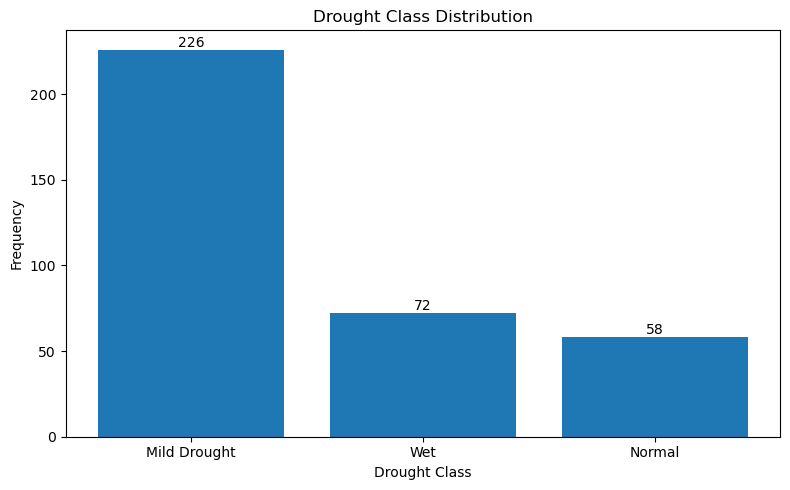

In [27]:


# Drought class distribution
classes = ["Mild Drought", "Wet", "Normal"]
counts = [226, 72, 58]

# Create figure
plt.figure(figsize=(8,5))

# Bar chart
bars = plt.bar(classes, counts)

# Title and labels
plt.title("Drought Class Distribution")
plt.xlabel("Drought Class")
plt.ylabel("Frequency")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

In [31]:
# Monthly climate aggregation
monthly_climate = (
    climate_df
    .groupby("YEAR_MONTH")
    .agg({
        "PRECIP": "sum",
        "RELHUM": "mean",
        "TMPMAX": "mean",
        "TMPMIN": "mean"
    })
    .reset_index()
)

# Convert period → timestamp
monthly_climate["DATE"] = (
    monthly_climate["YEAR_MONTH"]
    .dt
    .to_timestamp()
)

# Preview
monthly_climate.head()

,YEAR_MONTH,PRECIP,RELHUM,TMPMAX,TMPMIN,DATE
0,1993-01,7.20,49.131720,26.414516,7.890323,1993-01-01
1,1993-02,0.00,43.309524,27.367857,9.578571,1993-02-01
2,1993-03,12.85,41.020161,29.811290,12.354839,1993-03-01
3,1993-04,33.35,49.222222,29.175000,15.176667,1993-04-01
4,1993-05,72.40,53.014785,29.111290,15.000000,1993-05-01


In [32]:
# Merge climate variables with SPI dataframe
forecast_df = monthly_rainfall.merge(
    monthly_climate,
    on=["YEAR_MONTH", "DATE"],
    how="left"
)

# Preview
forecast_df.head()

,YEAR_MONTH,PRECIP_x,DATE,ROLLING_3,SPI_3,DROUGHT_CLASS,PRECIP_y,RELHUM,TMPMAX,TMPMIN
0,1993-03,12.85,1993-03-01,20.05,-0.893793,Mild Drought,12.85,41.020161,29.811290,12.354839
1,1993-04,33.35,1993-04-01,46.20,-0.830751,Mild Drought,33.35,49.222222,29.175000,15.176667
2,1993-05,72.40,1993-05-01,118.60,-0.656211,Mild Drought,72.40,53.014785,29.111290,15.000000
3,1993-06,251.20,1993-06-01,356.95,-0.081605,Mild Drought,251.20,67.130556,26.451667,14.625000
4,1993-07,439.45,1993-07-01,763.05,0.897408,Normal,439.45,77.182796,23.669355,14.416129


In [33]:
# Rename columns
forecast_df = forecast_df.rename(columns={
    "PRECIP_x": "MONTHLY_RAINFALL"
})

# Drop duplicate precipitation column
forecast_df = forecast_df.drop(columns=["PRECIP_y"])

# Preview
forecast_df.head()

,YEAR_MONTH,MONTHLY_RAINFALL,DATE,ROLLING_3,SPI_3,DROUGHT_CLASS,RELHUM,TMPMAX,TMPMIN
0,1993-03,12.85,1993-03-01,20.05,-0.893793,Mild Drought,41.020161,29.811290,12.354839
1,1993-04,33.35,1993-04-01,46.20,-0.830751,Mild Drought,49.222222,29.175000,15.176667
2,1993-05,72.40,1993-05-01,118.60,-0.656211,Mild Drought,53.014785,29.111290,15.000000
3,1993-06,251.20,1993-06-01,356.95,-0.081605,Mild Drought,67.130556,26.451667,14.625000
4,1993-07,439.45,1993-07-01,763.05,0.897408,Normal,77.182796,23.669355,14.416129


In [34]:
# SPI lag features
forecast_df["SPI_lag_1"] = (
    forecast_df["SPI_3"].shift(1)
)

forecast_df["SPI_lag_2"] = (
    forecast_df["SPI_3"].shift(2)
)

forecast_df["SPI_lag_3"] = (
    forecast_df["SPI_3"].shift(3)
)

In [35]:
# Rainfall lag features
forecast_df["RAIN_lag_1"] = (
    forecast_df["MONTHLY_RAINFALL"].shift(1)
)

forecast_df["RAIN_lag_2"] = (
    forecast_df["MONTHLY_RAINFALL"].shift(2)
)

forecast_df["RAIN_lag_3"] = (
    forecast_df["MONTHLY_RAINFALL"].shift(3)
)

In [36]:
# Rolling mean using ONLY past information
forecast_df["rolling_mean_3"] = (
    forecast_df["MONTHLY_RAINFALL"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Rolling std using ONLY past information
forecast_df["rolling_std_3"] = (
    forecast_df["MONTHLY_RAINFALL"]
    .shift(1)
    .rolling(window=3)
    .std()
)

In [37]:
# Extract month
forecast_df["MONTH"] = (
    forecast_df["DATE"].dt.month
)

# Extract year
forecast_df["YEAR"] = (
    forecast_df["DATE"].dt.year
)

In [38]:
# Remove rows with lag NaNs
forecast_df = forecast_df.dropna()

# Reset index
forecast_df = forecast_df.reset_index(drop=True)

# Preview
forecast_df.head()

,YEAR_MONTH,MONTHLY_RAINFALL,DATE,ROLLING_3,SPI_3,DROUGHT_CLASS,RELHUM,TMPMAX,TMPMIN,SPI_lag_1,SPI_lag_2,SPI_lag_3,RAIN_lag_1,RAIN_lag_2,RAIN_lag_3,rolling_mean_3,rolling_std_3,MONTH,YEAR
0,1993-06,251.2000,1993-06-01,356.9500,-0.081605,Mild Drought,67.130556,26.451667,14.625000,-0.656211,-0.830751,-0.893793,72.4000,33.3500,12.85,39.533333,30.252700,6,1993
1,1993-07,439.4500,1993-07-01,763.0500,0.897408,Normal,77.182796,23.669355,14.416129,-0.081605,-0.656211,-0.830751,251.2000,72.4000,33.35,118.983333,116.155761,7,1993
2,1993-08,409.6125,1993-08-01,1100.2625,1.710349,Wet,74.990591,24.241935,13.896774,0.897408,-0.081605,-0.656211,439.4500,251.2000,72.40,254.350000,183.545274,8,1993
3,1993-09,142.5875,1993-09-01,991.6500,1.448510,Wet,71.300000,24.630000,13.338333,1.710349,0.897408,-0.081605,409.6125,439.4500,251.20,366.754167,101.178768,9,1993
4,1993-10,78.5000,1993-10-01,630.7000,0.578343,Normal,65.448925,25.609677,13.554839,1.448510,1.710349,0.897408,142.5875,409.6125,439.45,330.550000,163.462519,10,1993


In [39]:
forecast_df.shape

(353, 19)

In [40]:
# Target variable
target = "SPI_3"

# Features
features = [
    "RELHUM",
    "TMPMAX",
    "TMPMIN",

    "SPI_lag_1",
    "SPI_lag_2",
    "SPI_lag_3",

    "RAIN_lag_1",
    "RAIN_lag_2",
    "RAIN_lag_3",

    "rolling_mean_3",
    "rolling_std_3",

    "MONTH"
]

# Feature matrix
X = forecast_df[features]

# Target vector
y = forecast_df[target]

In [41]:
# Train-test split index
split_index = int(len(forecast_df) * 0.8)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (282, 12)
Testing Shape: (71, 12)


In [42]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training only
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing
X_test_scaled = scaler.transform(X_test)

In [43]:
#Randomforest
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

# Train model
rf_model.fit(
    X_train_scaled,
    y_train
)

RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42)

In [44]:
# Predictions
rf_predictions = rf_model.predict(
    X_test_scaled
)

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Metrics
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest Performance
-------------------------
MAE : 0.2267
RMSE: 0.3147
R²  : 0.9006


In [46]:
#XGboost
!pip install xgboost

In [67]:
# Rebuild X and y
X = forecast_df[[
    'RELHUM',
    'TMPMAX',
    'TMPMIN',

    'SPI_lag_1',
    'SPI_lag_2',
    'SPI_lag_3',

    'RAIN_lag_1',
    'RAIN_lag_2',
    'RAIN_lag_3',

    'rolling_mean_3',
    'rolling_std_3',

    'MONTH'
]]

y = forecast_df["SPI_3"]

In [48]:
from xgboost import XGBRegressor

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [94]:
xgb_features = X.columns.tolist()

In [69]:


# Clean deployment model
xgb_model_clean = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train directly WITHOUT scaling
xgb_model_clean.fit(
    X_train,
    y_train
)

print("Clean XGBoost model trained.")

Clean XGBoost model trained.


In [74]:
# Generate predictions
xgb_predictions = xgb_model_clean.predict(
    X_test)


In [75]:
# XGBoost metrics
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Performance")
print("-------------------")
print("MAE :", round(xgb_mae, 4))
print("RMSE:", round(xgb_rmse, 4))
print("R²  :", round(xgb_r2, 4))

XGBoost Performance
-------------------
MAE : 0.2063
RMSE: 0.2931
R²  : 0.9138


In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [76]:
# Features for LSTM
lstm_features = features

# Convert to numpy
X_lstm = forecast_df[lstm_features].values

y_lstm = forecast_df["SPI_3"].values

In [115]:
# Scale all features
lstm_scaler = StandardScaler()

X_lstm_scaled = lstm_scaler.fit_transform(
    X_lstm
)

In [116]:
# Sequence length
sequence_length = 3

X_sequences = []
y_sequences = []

# Build sequences
for i in range(sequence_length, len(X_lstm_scaled)):

    X_sequences.append(
        X_lstm_scaled[i-sequence_length:i]
    )

    y_sequences.append(
        y_lstm[i]
    )

# Convert to arrays
X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

X shape: (350, 3, 12)
y shape: (350,)


In [143]:
# Split index
split_index_lstm = int(
    len(X_sequences) * 0.8
)

# Train
X_train_lstm = X_sequences[:split_index_lstm]
y_train_lstm = y_sequences[:split_index_lstm]

# Test
X_test_lstm = X_sequences[split_index_lstm:]
y_test_lstm = y_sequences[split_index_lstm:]

print("Train Shape:", X_train_lstm.shape)
print("Test Shape:", X_test_lstm.shape)

Train Shape: (280, 3, 12)
Test Shape: (70, 3, 12)


In [118]:
# Build LSTM model
lstm_model = Sequential()

# LSTM layer
lstm_model.add(
    LSTM(
        64,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    )
)

# Dropout
lstm_model.add(
    Dropout(0.2)
)

# Output layer
lstm_model.add(
    Dense(1)
)

# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

# Summary
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 64)                  │          19,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# Train LSTM
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,

    epochs=50,
    batch_size=16,

    validation_data=(
        X_test_lstm,
        y_test_lstm
    ),

    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.6354 - val_loss: 0.4188
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2472 - val_loss: 0.2538
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1667 - val_loss: 0.2423
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1292 - val_loss: 0.2097
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1283 - val_loss: 0.2250
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1166 - val_loss: 0.2158
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1165 - val_loss: 0.2061
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1123 - val_loss: 0.2121
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0976 - val_loss: 0.2021
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1027 - val_loss: 0.2030
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0984 - val_loss: 0.2127
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

In [120]:
# Generate predictions
lstm_predictions = lstm_model.predict(
    X_test_lstm
)

# Flatten predictions
lstm_predictions = lstm_predictions.flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step


In [121]:
# LSTM metrics
lstm_mae = mean_absolute_error(
    y_test_lstm,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        lstm_predictions
    )
)

lstm_r2 = r2_score(
    y_test_lstm,
    lstm_predictions
)

print("LSTM Performance")
print("----------------")
print("MAE :", round(lstm_mae, 4))
print("RMSE:", round(lstm_rmse, 4))
print("R²  :", round(lstm_r2, 4))

LSTM Performance
----------------
MAE : 0.2462
RMSE: 0.3352
R²  : 0.8854


In [122]:
#Update Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGboost",
        "LSTM"
    ],
    "MAE": [
       rf_mae,
      xgb_mae,
        lstm_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse,
        lstm_rmse
    ],
    "R2": [
       rf_r2,
        xgb_r2,
        lstm_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,0.226714,0.314650,0.900600
1,XGboost,0.206283,0.293078,0.913763
2,LSTM,0.246237,0.335184,0.885390


In [123]:
import joblib

joblib.dump(
    xgb_model_clean,
    "clean_drought_model.pkl"
)

print("Clean model saved.")

Clean model saved.


In [124]:
import pandas as pd
import numpy as np

def recursive_forecast(
    model,
    scaler,
    forecast_df,
    future_month,
    future_year
):

    # Copy latest data
    future_data = forecast_df.copy()

    # Last known date
    last_date = future_data["DATE"].max()

    # Target date
    target_date = pd.Timestamp(
        year=future_year,
        month=future_month,
        day=1
    )

    # Number of months to predict
    months_ahead = (
        (target_date.year - last_date.year) * 12
        +
        (target_date.month - last_date.month)
    )

    # Recursive forecasting loop
    for step in range(months_ahead):

        latest_row = future_data.iloc[-1]

        # Build next month date
        next_date = latest_row["DATE"] + pd.DateOffset(months=1)

        # Create new feature row
        new_row = {}

        new_row["DATE"] = next_date
        new_row["MONTH"] = next_date.month

        # Climate assumptions
        new_row["RELHUM"] = latest_row["RELHUM"]
        new_row["TMPMAX"] = latest_row["TMPMAX"]
        new_row["TMPMIN"] = latest_row["TMPMIN"]

        # SPI lags
        new_row["SPI_lag_1"] = latest_row["SPI_3"]
        new_row["SPI_lag_2"] = latest_row["SPI_lag_1"]
        new_row["SPI_lag_3"] = latest_row["SPI_lag_2"]

        # Rainfall lags
        new_row["RAIN_lag_1"] = latest_row["MONTHLY_RAINFALL"]
        new_row["RAIN_lag_2"] = latest_row["RAIN_lag_1"]
        new_row["RAIN_lag_3"] = latest_row["RAIN_lag_2"]

        # Rolling statistics
        rainfall_values = [
            new_row["RAIN_lag_1"],
            new_row["RAIN_lag_2"],
            new_row["RAIN_lag_3"]
        ]

        new_row["rolling_mean_3"] = np.mean(rainfall_values)
        new_row["rolling_std_3"] = np.std(rainfall_values)

        # Feature dataframe
        feature_df = pd.DataFrame([[
            new_row["RELHUM"],
            new_row["TMPMAX"],
            new_row["TMPMIN"],

            new_row["SPI_lag_1"],
            new_row["SPI_lag_2"],
            new_row["SPI_lag_3"],

            new_row["RAIN_lag_1"],
            new_row["RAIN_lag_2"],
            new_row["RAIN_lag_3"],

            new_row["rolling_mean_3"],
            new_row["rolling_std_3"],

            new_row["MONTH"]
        ]], columns=features)

        # Scale features
        scaled_features = scaler.transform(feature_df)

        # Predict SPI
        predicted_spi = model.predict(
            scaled_features
        )[0]

        # Save prediction
        new_row["SPI_3"] = predicted_spi

        # Approximate future rainfall
        new_row["MONTHLY_RAINFALL"] = max(
            0,
            latest_row["MONTHLY_RAINFALL"]
            * (1 + predicted_spi * 0.05)
        )

        # Append new row
        future_data = pd.concat([
            future_data,
            pd.DataFrame([new_row])
        ], ignore_index=True)

    # Final prediction
    final_prediction = future_data.iloc[-1]

    return final_prediction

In [126]:
# Example forecast
future_prediction = recursive_forecast(
    model=xgb_model_clean,
    scaler=scaler,
    forecast_df=forecast_df,

    future_month=1,
    future_year=2028
)

future_prediction

YEAR_MONTH                          NaT
MONTHLY_RAINFALL                    0.0
DATE                2028-01-01 00:00:00
ROLLING_3                           NaN
SPI_3                         -0.909654
DROUGHT_CLASS                       NaN
RELHUM                        56.329032
TMPMAX                             28.4
TMPMIN                         7.645161
SPI_lag_1                     -0.909654
SPI_lag_2                      -0.90862
SPI_lag_3                     -0.945938
RAIN_lag_1                          0.0
RAIN_lag_2                          0.0
RAIN_lag_3                          0.0
rolling_mean_3                      0.0
rolling_std_3                       0.0
MONTH                                 1
YEAR                                NaN
Name: 388, dtype: object

In [127]:
# Drought interpretation
def classify_drought(spi):

    if spi <= -2:
        return "Extreme Drought"

    elif spi <= -1.5:
        return "Severe Drought"

    elif spi <= -1:
        return "Moderate Drought"

    elif spi < 0:
        return "Mild Drought"

    elif spi < 1:
        return "Normal"

    else:
        return "Wet"

In [61]:
predicted_spi = future_prediction["SPI_3"]

predicted_class = classify_drought(
    predicted_spi
)

print("Forecast Date:")
print(
    future_prediction["DATE"]
)

print("\nPredicted SPI:")
print(
    round(predicted_spi, 3)
)

print("\nForecast Condition:")
print(predicted_class)

Forecast Date:
2028-01-01 00:00:00

Predicted SPI:
-0.539

Forecast Condition:
Mild Drought


In [129]:
y_pred = xgb_model_clean.predict(X_test)

In [130]:
import pandas as pd

results = pd.DataFrame({
    "Actual_SPI": y_test,
    "Predicted_SPI": y_pred
})

results.head()

,Actual_SPI,Predicted_SPI
282,1.424764,1.438030
283,1.691636,1.647747
284,0.735525,0.763459
285,-0.222755,-0.133571
286,-0.679596,-0.569364


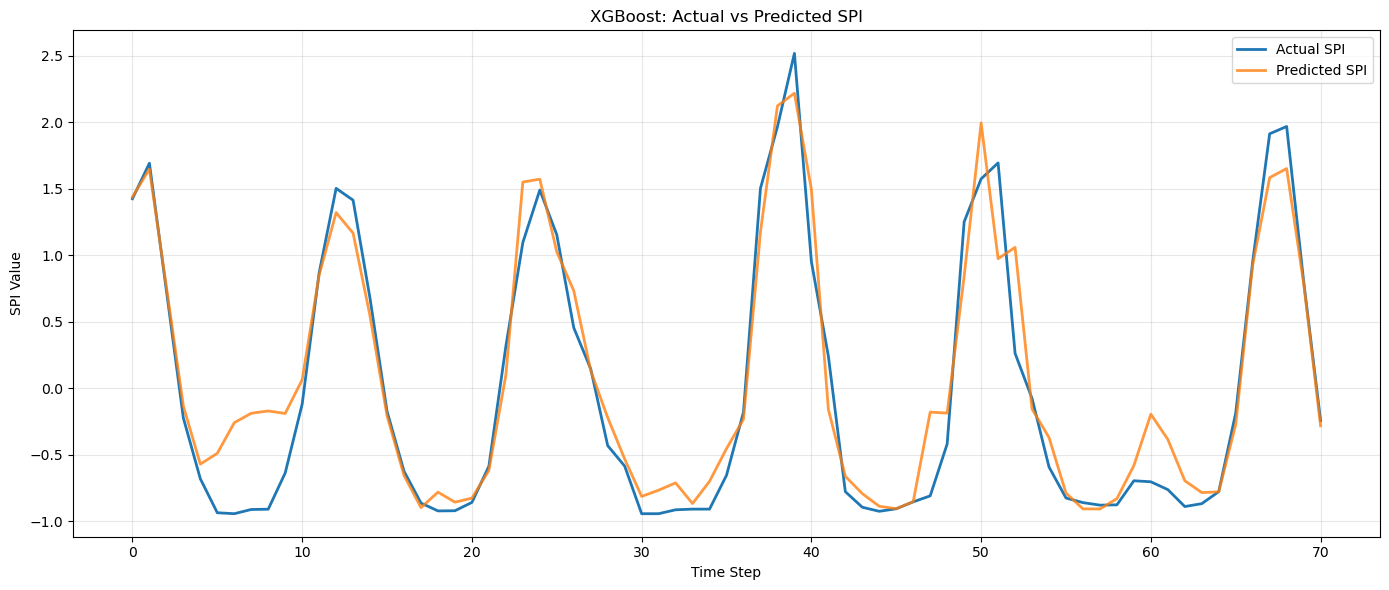

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual SPI", linewidth=2)
plt.plot(y_pred, label="Predicted SPI", linewidth=2, alpha=0.8)

plt.xlabel("Time Step")
plt.ylabel("SPI Value")
plt.title("XGBoost: Actual vs Predicted SPI")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [134]:
y_pred_lstm = lstm_model.predict(X_test)

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [135]:
print(type(X_test))
print(X_test.shape)

<class 'pandas.core.frame.DataFrame'>
(71, 12)


In [137]:
X_test = np.array(X_test)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

IndexError: tuple index out of range

In [138]:
---------------------------------------------------------------------------
IndexError                                Traceback (most recent call last)
Cell In[137], line 2
      1 X_test = np.array(X_test)
----> 2 X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

IndexError: tuple index out of range

SyntaxError: invalid syntax (2976843031.py, line 1)

In [139]:
import numpy as np

X_test = np.array(X_test)

print("Shape:", X_test.shape)
print("Dimensions:", X_test.ndim)

Shape: (71, 12)
Dimensions: 2


In [145]:
import numpy as np

def create_sequences(X, y, timesteps=3):
    Xs, ys = [], []

    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y[i+timesteps])

    return np.array(Xs), np.array(ys)

In [146]:
X_seq, y_seq = create_sequences(X.values, y.values, timesteps=3)

In [147]:
split = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:split]
X_test_lstm  = X_seq[split:]

y_train_lstm = y_seq[:split]
y_test_lstm  = y_seq[split:]

In [148]:
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = y_pred_lstm.reshape(-1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


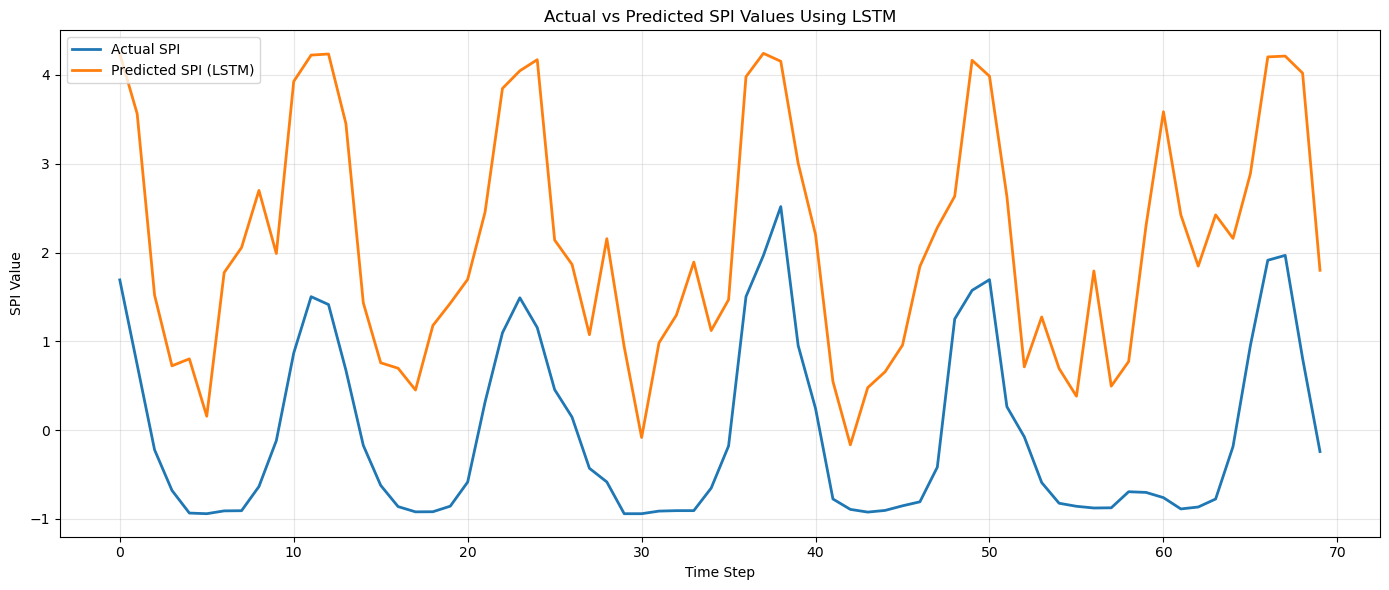

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test_lstm, label="Actual SPI", linewidth=2)
plt.plot(y_pred_lstm, label="Predicted SPI (LSTM)", linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("SPI Value")
plt.title("Actual vs Predicted SPI Values Using LSTM")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()